In [88]:
import pandas as pd 
from pathlib import Path
import re 
import json 
import matplotlib.pyplot as plt

In [89]:
p = Path("/home/finn/workspace/creatures/logs/simulation_1782625406.log")
assert p.exists()

In [90]:
with open(p, "r") as f:
    lines = f.readlines()

print(len(lines))

100133


In [ ]:
def extract_animal_data(line):
    # Match new log format: [unix_ts=...] [frame=...] animal_despawn reason=... lifetime_frames=... animal=Animal { ... }
    m = re.match(
        r".*"
        r"\[unix_ts=\d+\] \[frame=\d+\] animal_despawn "
        #r"reason=(?P<reason>\w+) "
        #r"lifetime_frames=(?P<lifetime>\d+) "
        # r"animal=Animal\s*\{\s*"
        # r"id:\s*(?P<id>\d+),\s*"
        # r"parent_id:\s*(?P<parent_id>Some\(\d+\)|None),\s*"
        # r"diet:\s*(?P<diet>\w+),\s*"
        # r".*?"  # Match everything up to spawn_at (position, velocity, energy, size, color, vision, genome)
        # r"spawn_at:\s*(?P<spawn_at>\d+),\s*"
        # r"despawn_at:\s*(?P<despawn_at>Some\(\d+\)|None),\s*"
        # r"family:\s*(?P<family>\d+)\s*\}",
        ".*"
        ,
        line,
    )

    if m is not None:
        d = {}
        d["reason"] = m.group("reason")
        d["spawn_at"] = float(m.group("spawn_at"))
        d["despawn_at"] = float(m.group("despawn_at").replace("Some(", "").rstrip(")")) \
            if "Some" in m.group("despawn_at") else None
        d["lifetime"] = float(m.group("lifetime"))
        d["diet"] = m.group("diet")
        d["family"] = int(m.group("family"))
        d["id"] = int(m.group("id"))
        d["parent_id"] = int(m.group("parent_id").replace("Some(", "").rstrip(")")) \
            if "Some" in m.group("parent_id") else None
        return d
    return None


In [86]:
df = pd.DataFrame(list(filter(None, map(extract_animal_data, lines))))


In [87]:
df

""


In [28]:
df.sort_values("lifetime")

KeyError: 'lifetime'

In [91]:
def extract_population_data(line):
    line = re.sub(
        r"animals=\{carnivores:(\d+)\s+herbivores:(\d+)\s+omnivores:(\d+)\}",
        r'animals={"carnivores":\1,"herbivores":\2,"omnivores":\3}',
        line,
    )
    m = re.match(
        r".*frame=(?P<frame>\d+).*population_size plants=(?P<n_plants>\d+)\s+animals=(?P<json>\{.*?\})\s+families=(?P<families>\d+:\d+(?:\|\d+:\d+)*).*",
        line,
    )
    if m is not None:
        d = {}
        d["frame"] = int(m.group("frame"))
        d["n_plants"] = int(m.group("n_plants"))
        json_data = json.loads(m.group("json"))
        d["carnivores"] = int(json_data.get("carnivores", 0))
        d["herbivores"] = int(json_data.get("herbivores", 0))
        d["omnivores"] = int(json_data.get("omnivores", 0))
        d["families"] = m.group("families")
        return d
    return m     

In [95]:
df = pd.DataFrame(list(filter(None, map(extract_population_data, lines)))).set_index("frame")
df

,n_plants,carnivores,herbivores,omnivores,families
frame,,,,,
23,10,1,1,0,0:1|348019602:1
24,11,1,1,0,0:1|348019602:1
29,12,1,1,0,0:1|348019602:1
61,13,1,1,0,0:1|348019602:1
64,14,1,1,0,0:1|348019602:1
...,...,...,...,...,...
287768,22,0,0,22,551986525:21|1012684669:1
287786,23,0,0,22,551986525:21|1012684669:1
287794,24,0,0,22,551986525:21|1012684669:1


# Genetic DIversity

In [96]:

df["families"] = df["families"].str.split("|").apply(lambda x: [tuple(map(int, f.split(":"))) for f in x])

<Axes: xlabel='frame'>

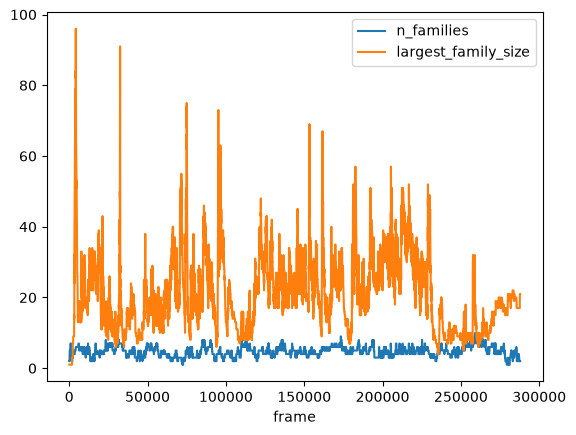

In [97]:
def f(x):
    return {"n_families": len(x), "largest_family_size": max(x, key=lambda i: i[1])[1]}
df_fam = df["families"].apply(f).apply(pd.Series)
df_fam.plot()

# Population

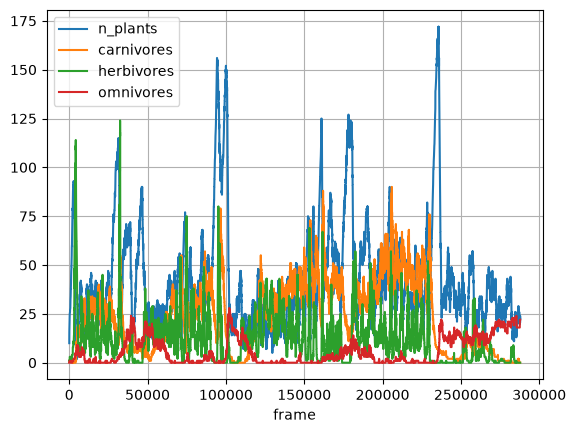

In [98]:
#df["n_plants"].plot()
df.plot()
plt.grid()
plt.legend()